In [1]:
import importlib
import pandas as pd
from IPython.display import display
import framework
importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


CHANGE ACCORDING TO YOUR PATHS !!

In [2]:

# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


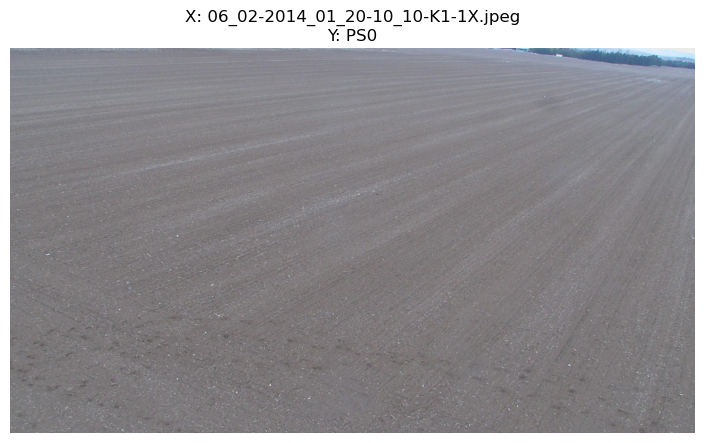

In [3]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,92,12,15,6,14,21,12,28,200
6,22,20,34,28,47,4,18,16,189
10,31,24,18,28,35,13,25,14,188
1,20,19,37,15,47,12,8,23,181
9,101,17,15,5,15,8,20,0,181
2,12,37,21,24,22,9,19,30,174
3,19,22,26,40,26,14,11,16,174
4,7,37,5,18,36,15,13,31,162
8,45,14,17,4,39,21,3,17,160



Stage totals:


,count
label,
PS0,360
PS1,220
PS2,208
PS3,189
PS4,306
PS5,123
PS6,143
PS7,193


In [5]:
missing_data_per_station, missing_dates_for_stations = wf.get_stagewise_missing_data()



Stage: PS0

Stage: PS1

Stage: PS2

Stage: PS3


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in


Stage: PS4

Stage: PS5

Stage: PS6

Stage: PS7


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in

In [6]:

print("\nMissing data per station:")
##make a table with station, stage, and only missing count
print("Station\t", end="")
for i in range(1,9):
    print(f"\tPS{i}", end="")
print()
for station, stages in missing_data_per_station.items():
    print(f"{station}", end="")
    for stage, info in stages.items():
        print(f"\t{info['missing_count']}", end="")
    print()


Missing data per station:
Station		PS1	PS2	PS3	PS4	PS5	PS6	PS7	PS8
02.02_2014	2	1	0	0	9	4	3	12
02.03_2013	2	14	3	11	14	0	2	1
02.03_2014	1	0	3	14	4	6	2	6
02.04_2013	14	7	13	1	9	0	0	-1
02.05_2013	29	0	7	5	20	2	8	17
02.06_2016	3	14	2	1	0	10	2	-1
06.01_2013	21	13	0	0	15	2	0	-1
06.02_2013	10	2	8	14	5	0	15	3
06.02_2016	62	4	6	4	17	2	13	15
11.03_2016	18	4	2	0	4	8	0	1


In [7]:
missing_data_per_station["02.06_2016"]

{'PS0': {'missing_count': 3,
  'total_days': 25,
  'data_count': 22,
  'days': {'start': Timestamp('2016-11-12 00:00:00'),
   'end': Timestamp('2016-12-07 00:00:00'),
   'days': 25}},
 'PS1': {'missing_count': 14,
  'total_days': 34,
  'data_count': 20,
  'days': {'start': Timestamp('2016-12-07 00:00:00'),
   'end': Timestamp('2017-01-10 00:00:00'),
   'days': 34}},
 'PS2': {'missing_count': 2,
  'total_days': 36,
  'data_count': 34,
  'days': {'start': Timestamp('2017-01-10 00:00:00'),
   'end': Timestamp('2017-02-15 00:00:00'),
   'days': 36}},
 'PS3': {'missing_count': 1,
  'total_days': 29,
  'data_count': 28,
  'days': {'start': Timestamp('2017-02-15 00:00:00'),
   'end': Timestamp('2017-03-16 00:00:00'),
   'days': 29}},
 'PS4': {'missing_count': 0,
  'total_days': 47,
  'data_count': 47,
  'days': {'start': Timestamp('2017-03-16 00:00:00'),
   'end': Timestamp('2017-05-02 00:00:00'),
   'days': 47}},
 'PS5': {'missing_count': 10,
  'total_days': 14,
  'data_count': 4,
  'days': 

In [8]:
missing_dates_for_stations

{'02.02_2014': {Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00'),
  Timestamp('2015-06-14 00:00:00'),
  Timestamp('2015-06-15 00:00:00'),
  Timestamp('2015-06-16 00:00:00'),
  Timestamp('2015-06-17 00:00:00'),
  Timestamp('2015-06-18 00:00:00'),
  Timestamp('2015-06-19 00:00:00'),
  Timestamp('2015-06-30 00:00:00'),
  Timestamp('2015-07-01 00:00:00')},
 '02.03_2013': {Timestamp('2014-05-30 00:00:00'),
  Timestamp('2014-06-12 00:00:00')},
 '02.03_2014': {Timestamp('2015-05-24 00:00:00'),
  Timestamp('2015-05-25 00:00:00'),
  Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00')},
 '02.04_2013': {Timestamp('2014-03-17 00:00:00'),
  Timestamp('2014-03-18 00:00:00'),
  Timestamp('2014-03-19 00:00:00'),
  Timestamp('2014-03-20 00:00:00'),
  Tim

In [9]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=1361, test_samples=381
 Fold 2: train_samples=1380, test_samples=362
 Fold 3: train_samples=1387, test_samples=355
 Fold 4: train_samples=1406, test_samples=336
 Fold 5: train_samples=1387, test_samples=355


YOUR CODE HERE

In [10]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts


In [11]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from framework import generate_group_folds, run_fold_with_trainer

# 1. Feature Engineering: Extract the date directly from the filename path
def prepare_date_features_from_path(df):
    df = df.copy()
    
    # Regex to find an 8-digit date (YYYYMMDD) in the path string
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        return match.group(1) if match else None

    df['extracted_date'] = df['path'].apply(extract_date)
    
    # print("\nExtracted dates from paths (sample):")
    # display(df[['path', 'extracted_date']].head(10))
    # Convert to datetime
    df['dt'] = pd.to_datetime(df['extracted_date'], format='%Y_%m_%d', errors='coerce')
    
    # Extract temporal features. Fill missing dates with -1 to prevent NaN crashes
    df['day_of_year'] = df['dt'].dt.dayofyear.fillna(-1)
    df['month'] = df['dt'].dt.month.fillna(-1)
    # print("\nExtracted temporal features (sample):")
    # display(df[['path', 'extracted_date', 'day_of_year', 'month']].head(10))

    # Convert station_year to a numerical category so the model knows which field it's looking at
    df['station_code'] = pd.factorize(df['station_year'])[0]
    
    return df

# 2. Random Forest Trainer
def date_baseline_trainer(train_df, test_df, fold_id, config):
    # Prepare features for both sets
    train_df = prepare_date_features_from_path(train_df)
    test_df = prepare_date_features_from_path(test_df)
    
    # Use temporal and location features
    features = ['day_of_year', 'month', 'station_code']
    
    X_train = train_df[features]
    y_train = train_df['label']
    
    X_test = test_df[features]
    y_test = test_df['label']
    
    # Random Forest handles categorical features and non-linear thresholds well
    model = RandomForestClassifier(
        n_estimators=config.get('n_estimators', 200),
        max_depth=config.get('max_depth', 10),
        random_state=42
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': y_test.values,
        'pred': preds
    })
    
    metrics = {'accuracy': accuracy_score(pred_df['true'], pred_df['pred'])}
    
    print(f"✅ Date Baseline Fold {fold_id} Accuracy: {metrics['accuracy']:.4f}")
    return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# 3. K-Fold Execution using your actual group_id
date_config = {
    'n_estimators': 200,
    'max_depth': 8
}

# CRITICAL FIX: Explicitly passing 'group_col="group_id"' based on your dataframe columns
# This ensures 8 groups in train and 2 in test
folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)

date_results = []
for f_idx, (tr_idx, te_idx) in enumerate(folds):
    res = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: date_baseline_trainer(tr, te, fid, date_config),
        fold_id=f_idx + 1
    )
    date_results.append(res['metrics']['accuracy'])

print(f"\n{'='*40}")
print(f"FINAL DATE-ONLY MEAN ACCURACY: {np.mean(date_results):.4f}")
print(f"{'='*40}")

✅ Date Baseline Fold 1 Accuracy: 0.2730
✅ Date Baseline Fold 2 Accuracy: 0.4420
✅ Date Baseline Fold 3 Accuracy: 0.6282
✅ Date Baseline Fold 4 Accuracy: 0.5595
✅ Date Baseline Fold 5 Accuracy: 0.4028

FINAL DATE-ONLY MEAN ACCURACY: 0.4611


In [12]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from framework import generate_group_folds, run_fold_with_trainer

# --- 1. Coordinate Dictionary for Turkey's 81 Provinces ---
# Mapped by plate code (1-81) to (Latitude, Longitude)
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85) # Fallback to Ankara if plate is invalid

# --- 2. Advanced Feature Engineering ---
def prepare_advanced_features(df):
    df = df.copy()
    
    # ---------------- A. Agricultural Calendar (Starting Nov 1) ----------------
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        return match.group(1) if match else None

    df['dt'] = pd.to_datetime(df['path'].apply(extract_date), format='%Y_%m_%d', errors='coerce')
    
    # Logic to calculate "Days since Nov 1st of the planting season"
    def get_agricultural_doy(date):
        if pd.isna(date):
            return -1
        # If the month is before Nov, the planting season started the previous year
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    
    # ---------------- B. Geographic Coordinates ----------------
    # Extract the first 2 digits from the station_year string
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    
    return df

# --- 3. Enhanced Random Forest Trainer ---
def advanced_baseline_trainer(train_df, test_df, fold_id, config):
    train_df = prepare_advanced_features(train_df)
    test_df = prepare_advanced_features(test_df)
    
    # We now have highly specific biological features!
    features = ['agri_day_of_year', 'latitude', 'longitude']
    # features = ['longitude']
    
    X_train = train_df[features]
    y_train = train_df['label']
    
    X_test = test_df[features]
    y_test = test_df['label']
    
    # Gradient Boosting / Random Forest handles coordinate boundaries perfectly
    model = RandomForestClassifier(
        n_estimators=config.get('n_estimators', 300),
        max_depth=config.get('max_depth', 12),
        min_samples_split=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': y_test.values,
        'pred': preds
    })
    
    metrics = {'accuracy': accuracy_score(pred_df['true'], pred_df['pred'])}
    
    # Show feature importance for debugging
    importances = model.feature_importances_
    print(f"✅ Fold {fold_id} | Acc: {metrics['accuracy']:.4f} | Weights: Day({importances[0]:.2f}), Lat({importances[1]:.2f}), Lon({importances[2]:.2f})")
    
    return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# --- 4. Execution ---
rf_config = {
    'n_estimators': 300,
    'max_depth': 12
}

folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)

advanced_results = []
for f_idx, (tr_idx, te_idx) in enumerate(folds):
    res = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: advanced_baseline_trainer(tr, te, fid, rf_config),
        fold_id=f_idx + 1
    )
    advanced_results.append(res['metrics']['accuracy'])

print(f"\n{'='*50}")
print(f"FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: {np.mean(advanced_results):.4f}")
print(f"{'='*50}")

✅ Fold 1 | Acc: 0.5617 | Weights: Day(0.96), Lat(0.02), Lon(0.02)
✅ Fold 2 | Acc: 0.5994 | Weights: Day(0.93), Lat(0.04), Lon(0.04)
✅ Fold 3 | Acc: 0.7239 | Weights: Day(0.90), Lat(0.05), Lon(0.05)
✅ Fold 4 | Acc: 0.6964 | Weights: Day(0.91), Lat(0.05), Lon(0.05)
✅ Fold 5 | Acc: 0.6141 | Weights: Day(0.93), Lat(0.03), Lon(0.03)

FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: 0.6391


In [13]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from framework import generate_group_folds, run_fold_with_trainer

# --- 1. Coordinate Dictionary for Turkey's 81 Provinces ---
# Mapped by plate code (1-81) to (Latitude, Longitude)
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85) # Fallback to Ankara if plate is invalid

# --- 2. Advanced Feature Engineering ---
def prepare_advanced_features(df):
    df = df.copy()
    
    # ---------------- A. Agricultural Calendar (Starting Nov 1) ----------------
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        return match.group(1) if match else None

    df['dt'] = pd.to_datetime(df['path'].apply(extract_date), format='%Y_%m_%d', errors='coerce')
    
    # Logic to calculate "Days since Nov 1st of the planting season"
    def get_agricultural_doy(date):
        if pd.isna(date):
            return -1
        # If the month is before Nov, the planting season started the previous year
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    
    # ---------------- B. Geographic Coordinates ----------------
    # Extract the first 2 digits from the station_year string
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    
    return df

# --- 3. Enhanced Random Forest Trainer ---
def advanced_baseline_trainer(train_df, test_df, fold_id, config):
    train_df = prepare_advanced_features(train_df)
    test_df = prepare_advanced_features(test_df)
    
    # We now have highly specific biological features!
    features = ['agri_day_of_year']
    # features = ['longitude']
    
    X_train = train_df[features]
    y_train = train_df['label']
    
    X_test = test_df[features]
    y_test = test_df['label']
    
    # Gradient Boosting / Random Forest handles coordinate boundaries perfectly
    model = RandomForestClassifier(
        n_estimators=config.get('n_estimators', 300),
        max_depth=config.get('max_depth', 12),
        min_samples_split=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': y_test.values,
        'pred': preds
    })
    
    metrics = {'accuracy': accuracy_score(pred_df['true'], pred_df['pred'])}
    
    # Show feature importance for debugging
    importances = model.feature_importances_
    print(f"✅ Fold {fold_id} | Acc: {metrics['accuracy']:.4f} | Weights: Day({importances[0]:.2f})")
    
    return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# --- 4. Execution ---
rf_config = {
    'n_estimators': 300,
    'max_depth': 12
}

folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)

advanced_results = []
for f_idx, (tr_idx, te_idx) in enumerate(folds):
    res = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: advanced_baseline_trainer(tr, te, fid, rf_config),
        fold_id=f_idx + 1
    )
    advanced_results.append(res['metrics']['accuracy'])

print(f"\n{'='*50}")
print(f"FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: {np.mean(advanced_results):.4f}")
print(f"{'='*50}")

✅ Fold 1 | Acc: 0.2310 | Weights: Day(1.00)
✅ Fold 2 | Acc: 0.4254 | Weights: Day(1.00)
✅ Fold 3 | Acc: 0.5746 | Weights: Day(1.00)
✅ Fold 4 | Acc: 0.5268 | Weights: Day(1.00)
✅ Fold 5 | Acc: 0.3887 | Weights: Day(1.00)

FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: 0.4293


In [15]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from framework import generate_group_folds, run_fold_with_trainer

# --- 1. Coordinate Dictionary for Turkey's 81 Provinces ---
# Mapped by plate code (1-81) to (Latitude, Longitude)
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85) # Fallback to Ankara if plate is invalid

# --- 2. Advanced Feature Engineering ---
def prepare_advanced_features(df):
    df = df.copy()
    
    # ---------------- A. Agricultural Calendar (Starting Nov 1) ----------------
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        return match.group(1) if match else None

    df['dt'] = pd.to_datetime(df['path'].apply(extract_date), format='%Y_%m_%d', errors='coerce')
    
    # Logic to calculate "Days since Nov 1st of the planting season"
    def get_agricultural_doy(date):
        if pd.isna(date):
            return -1
        # If the month is before Nov, the planting season started the previous year
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    
    # ---------------- B. Geographic Coordinates ----------------
    # Extract the first 2 digits from the station_year string
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    
    return df

# --- 3. Enhanced Random Forest Trainer ---
def advanced_baseline_trainer(train_df, test_df, fold_id, config):
    train_df = prepare_advanced_features(train_df)
    test_df = prepare_advanced_features(test_df)
    
    # We now have highly specific biological features!
    features = ['longitude', 'latitude']
    # features = ['longitude']
    
    X_train = train_df[features]
    y_train = train_df['label']
    
    X_test = test_df[features]
    y_test = test_df['label']
    
    # Gradient Boosting / Random Forest handles coordinate boundaries perfectly
    model = RandomForestClassifier(
        n_estimators=config.get('n_estimators', 300),
        max_depth=config.get('max_depth', 12),
        min_samples_split=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': y_test.values,
        'pred': preds
    })
    
    metrics = {'accuracy': accuracy_score(pred_df['true'], pred_df['pred'])}
    
    # Show feature importance for debugging
    importances = model.feature_importances_
    print(f"✅ Fold {fold_id} | Acc: {metrics['accuracy']:.4f} | Weights: Lat ({importances[0]:.2f}), Lon ({importances[1]:.2f})")
    
    return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# --- 4. Execution ---
rf_config = {
    'n_estimators': 300,
    'max_depth': 12
}

folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)

advanced_results = []
for f_idx, (tr_idx, te_idx) in enumerate(folds):
    res = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: advanced_baseline_trainer(tr, te, fid, rf_config),
        fold_id=f_idx + 1
    )
    advanced_results.append(res['metrics']['accuracy'])

print(f"\n{'='*50}")
print(f"FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: {np.mean(advanced_results):.4f}")
print(f"{'='*50}")

✅ Fold 1 | Acc: 0.5066 | Weights: Lat (0.52), Lon (0.48)
✅ Fold 2 | Acc: 0.4088 | Weights: Lat (0.52), Lon (0.48)
✅ Fold 3 | Acc: 0.2056 | Weights: Lat (0.52), Lon (0.48)
✅ Fold 4 | Acc: 0.1845 | Weights: Lat (0.52), Lon (0.48)
✅ Fold 5 | Acc: 0.3465 | Weights: Lat (0.52), Lon (0.48)

FINAL AGRI-CALENDAR & GEO MEAN ACCURACY: 0.3304
